# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

In [80]:
numberOfCampaigns = 17

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [81]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split

Load both the full dataset and sample dataset.
We will need the sample dataset for running SVM as running it on the full dataset is untenable.

In [82]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')
dfSample = pd.read_csv('data/bank-additional.csv', sep = ';')

In [83]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



Check if data is missing

In [84]:
print (df.isnull().sum())
print (dfSample.isnull().sum())

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


### Observations:

It appears that there are no null columns in the data.
We will do the following:
- Drop the duration column from the dataset.
- Set up appropriate transformers for columns:
   - Numeric columns can simply use the standard scaler.
   - For categorical columns, we can use OneHotEncoder.
- Transform y using a map where yes = 1 and no = 0

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

### Business objective

The business objective is to first compare model efficacy, and then use a particular model to predict whether a client will subscribe to a term deposit (y) so the bank can target marketing calls efficiently and improve campaign conversion rates while reducing wasted outreach.


### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

Prepare the pre processor Pipeline and setup X and y

In [85]:
# Drop duration per problem description
model_df = df.drop(columns=["duration"]).copy()
model_dfSample = dfSample.drop(columns=["duration"]).copy()

# Features/target
X = model_df.drop(columns=["y"])
X_sample = model_dfSample.drop(columns=["y"])
y_original_categorical = model_df["y"]
y_sample_original_categorical = model_dfSample["y"]
y = model_df["y"].map({'yes': 1, 'no': 0})
y_sample = model_dfSample["y"].map({'yes': 1, 'no': 0})

# Define categorical and numeric columns for preprocessing based on X
# X is defined in W4O2kfVrnZbN and does not contain 'y'.
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("numeric", StandardScaler(), numeric_cols),
    ]
)
preprocessor

ColumnTransformer(transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')),
                                ('numeric', StandardScaler(),
                                 Index(['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object'))])

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [86]:


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_sample_train, X_sample_test, y_sample_train, y_sample_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42)

Check how well distributed the values are.  Based on what well balanced the dataset is, we will use different scoring techniques.

In [87]:
print("Class distribution in training set:")
print(y_train.value_counts(normalize=True))

print("\nClass distribution in testing set:")
print(y_test.value_counts(normalize=True))

print("\nClass distribution in training set (sample):")
print(y_sample_train.value_counts(normalize=True))

print("\nClass distribution in testing set (sample):")
print(y_sample_test.value_counts(normalize=True))


Class distribution in training set:
y
0    0.887557
1    0.112443
Name: proportion, dtype: float64

Class distribution in testing set:
y
0    0.886502
1    0.113498
Name: proportion, dtype: float64

Class distribution in training set (sample):
y
0    0.891047
1    0.108953
Name: proportion, dtype: float64

Class distribution in testing set (sample):
y
0    0.88835
1    0.11165
Name: proportion, dtype: float64


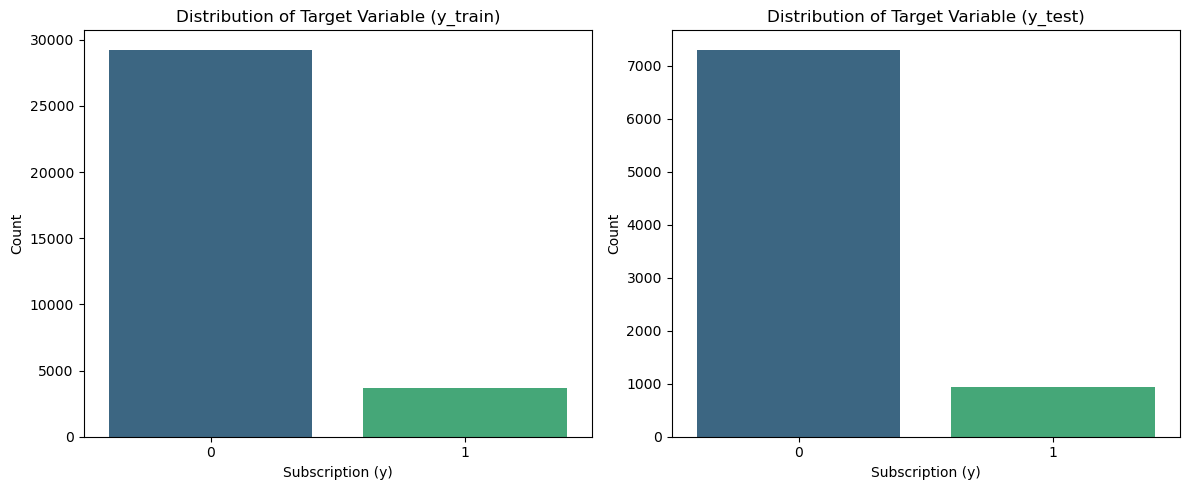

In [88]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=y_train, hue=y_train, ax=axes[0], palette='viridis', legend=False)
axes[0].set_title('Distribution of Target Variable (y_train)')
axes[0].set_xlabel('Subscription (y)')
axes[0].set_ylabel('Count')

sns.countplot(x=y_test, hue=y_test, ax=axes[1], palette='viridis', legend=False)
axes[1].set_title('Distribution of Target Variable (y_test)')
axes[1].set_xlabel('Subscription (y)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [89]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

# Initialize DummyClassifier with default 'prior' strategy and no random_state
dummy_classifier = DummyClassifier()

# Measure fit time
start_time = time.time()
dummy_classifier.fit(X_train, y_train)
end_time = time.time()
dummy_fit_time = end_time - start_time

# Predict on training and test sets
y_train_pred_dummy = dummy_classifier.predict(X_train)
y_test_pred_dummy = dummy_classifier.predict(X_test)

# Calculate accuracy
baseline_train_accuracy = accuracy_score(y_train, y_train_pred_dummy)
baseline_test_accuracy = accuracy_score(y_test, y_test_pred_dummy)

# Calculate additional metrics on the test set, specifying 'yes' as the positive label
baseline_test_precision = precision_score(y_test, y_test_pred_dummy, zero_division=0)
baseline_test_recall = recall_score(y_test, y_test_pred_dummy, zero_division=0)
baseline_test_f1 = f1_score(y_test, y_test_pred_dummy, zero_division=0)

print ("Baseline performance our classifier should aim to beat")
print(f"Dummy Classifier Fit Time: {dummy_fit_time:.4f} seconds")
print(f"Baseline Train Accuracy: {baseline_train_accuracy:.4f}")
print(f"Baseline Test Accuracy: {baseline_test_accuracy:.4f}")
print(f"Baseline Test Precision: {baseline_test_precision:.4f}")
print(f"Baseline Test Recall: {baseline_test_recall:.4f}")
print(f"Baseline Test F1-Score: {baseline_test_f1:.4f}")

Baseline performance our classifier should aim to beat
Dummy Classifier Fit Time: 0.0012 seconds
Baseline Train Accuracy: 0.8876
Baseline Test Accuracy: 0.8865
Baseline Test Precision: 0.0000
Baseline Test Recall: 0.0000
Baseline Test F1-Score: 0.0000


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [90]:
log_reg_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression())
    ]
)
log_reg_pipeline

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')),
                                                 ('numeric', StandardScaler(),
                                                  Index(['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object'))])),
                ('model', LogisticRegression())])

In [91]:
log_reg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')),
                                                 ('numeric', StandardScaler(),
                                                  Index(['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object'))])),
                ('model', LogisticRegression())])

### Problem 9: Score the Model

What is the accuracy of your model?

In [92]:
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Measure predict time
start_time = time.time()
y_pred_log_reg = log_reg_pipeline.predict(X_test)
end_time = time.time()
log_reg_predict_time = end_time - start_time

# Calculate accuracy
log_reg_accuracy = accuracy_score(y_test, y_pred_log_reg)

# Calculate additional metrics on the test set
log_reg_precision = precision_score(y_test, y_pred_log_reg, zero_division=0)
log_reg_recall = recall_score(y_test, y_pred_log_reg, zero_division=0)
log_reg_f1 = f1_score(y_test, y_pred_log_reg, zero_division=0)

print(f"Logistic Regression Predict Time: {log_reg_predict_time:.4f} seconds")
print(f"Logistic Regression Test Accuracy: {log_reg_accuracy:.4f}")
print(f"Logistic Regression Test Precision: {log_reg_precision:.4f}")
print(f"Logistic Regression Test Recall: {log_reg_recall:.4f}")
print(f"Logistic Regression Test F1-Score: {log_reg_f1:.4f}")

Logistic Regression Predict Time: 0.0196 seconds
Logistic Regression Test Accuracy: 0.8971
Logistic Regression Test Precision: 0.6417
Logistic Regression Test Recall: 0.2107
Logistic Regression Test F1-Score: 0.3172


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

***All Metrics Comparison Across Models***

In [93]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time
import pandas as pd

# Create a dictionary of model instances (not pipelines)
models = {
    "Logistic Regression": LogisticRegression(),
    "K Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Support Vector Machine": SVC()
}

results = []

for model_name, model_instance in models.items():
    print(f"\nEvaluating {model_name}...")

    # Create a pipeline for the current model
    pipeline = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", model_instance)
        ]
    )

    # Measure fit time
    start_time = time.time()
    pipeline.fit(X_train, y_train)
    fit_time = time.time() - start_time

    # Predict on training and test sets
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    # Measure predict time on test set
    start_time = time.time()
    _ = pipeline.predict(X_test) # Re-predict to get accurate predict time separate from y_test_pred calc
    predict_time = time.time() - start_time

    # Calculate metrics on the training set
    train_accuracy = accuracy_score(y_train, y_train_pred)

    # Calculate metrics on the test set
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, zero_division=0)
    test_recall = recall_score(y_test, y_test_pred, zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, zero_division=0)

    results.append({
        "Model": model_name,
        "Fit Time (s)": fit_time,
        "Predict Time (s)": predict_time,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Test Precision": test_precision,
        "Test Recall": test_recall,
        "Test F1-Score": test_f1
    })

# Create DataFrame from results
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Test F1-Score', ascending=False)
print("Model Comparison Results (Sorted by Test F1-Score):")
display(results_df)


Evaluating Logistic Regression...

Evaluating K Nearest Neighbors...

Evaluating Decision Tree...

Evaluating Support Vector Machine...
Model Comparison Results (Sorted by Test F1-Score):


,Model,Fit Time (s),Predict Time (s),Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1-Score
1,K Nearest Neighbors,0.062028,0.151343,0.914264,0.888080,0.512195,0.291979,0.371935
3,Support Vector Machine,41.923124,6.269251,0.904765,0.896941,0.612565,0.250267,0.355353
2,Decision Tree,0.188872,0.009016,0.995357,0.839403,0.313462,0.348663,0.330127
0,Logistic Regression,0.168566,0.011311,0.901275,0.897062,0.641694,0.210695,0.317230


***All Metrics Comparison Across Models Heat map***

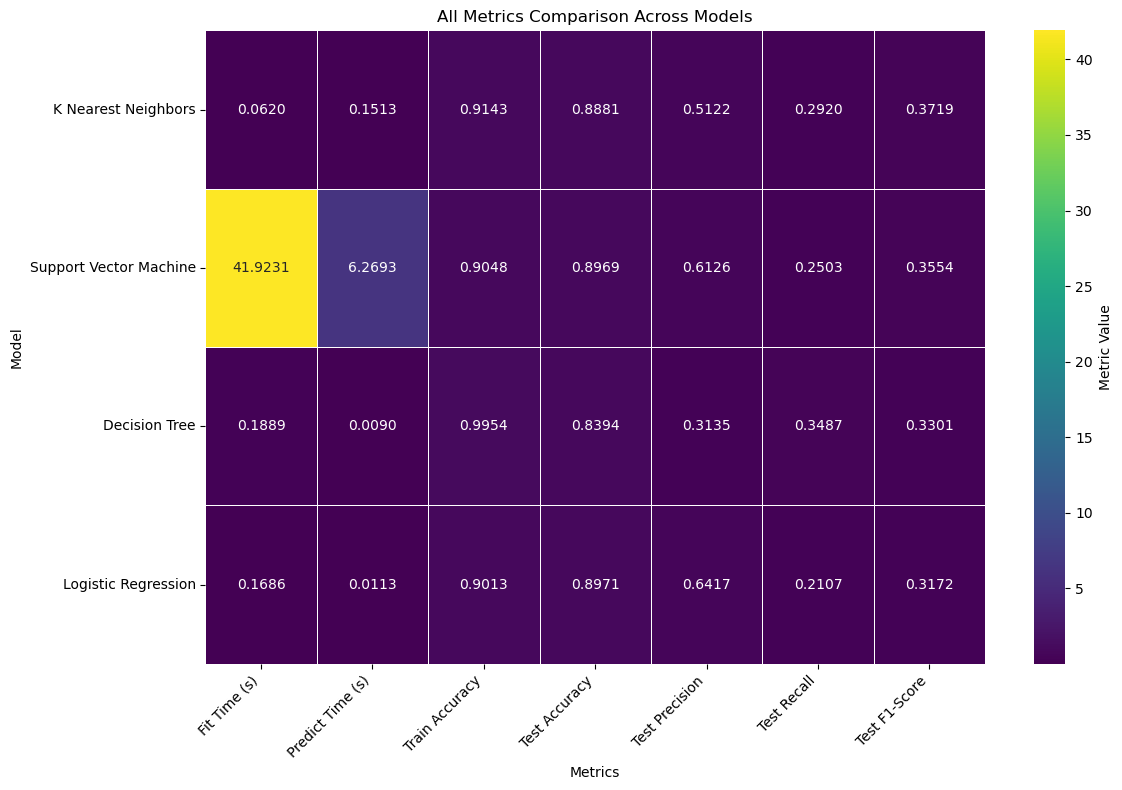

In [94]:
heatmap_data = results_df.set_index('Model')

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap='viridis', fmt=".4f", linewidths=.5, cbar_kws={'label': 'Metric Value'})
plt.title('All Metrics Comparison Across Models')
plt.ylabel('Model')
plt.xlabel('Metrics')
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

Note:  I initially attempted to "better" all 4 models using the complete dataset, but gave up given I don't have enough compute power to tear through gridsearchCV on hogs like SVM.  Running the analysis instead on the sample dataset.

*** All Metrics Comparison Across Tuned Models ***

Best Tuned Model Metrics:


,model,best_params,fit_time_seconds,predict_time_seconds,train_accuracy,train_precision,train_recall,train_f1,test_accuracy,test_precision,test_recall,test_f1
0,dummy,{'dummy__strategy': 'most_frequent'},8.712229,0.003367,0.891047,0.000000,0.000000,0.000000,0.888350,0.000000,0.000000,0.000000
1,knn,{'knn__n_neighbors': 7},0.612979,0.042191,0.904097,0.640523,0.272981,0.382812,0.893204,0.558824,0.206522,0.301587
2,logisticregression,{'logisticregression__C': 0.1},0.110144,0.004503,0.818513,0.326055,0.623955,0.428298,0.813107,0.327778,0.641304,0.433824
3,svc,"{'svc__C': 1, 'svc__kernel': 'rbf'}",3.380836,0.129051,0.867982,0.434028,0.696379,0.534759,0.858010,0.407407,0.597826,0.484581
4,decisiontree,{'decisiontree__max_depth': 15},0.094454,0.002435,0.963581,0.749478,1.000000,0.856802,0.817961,0.250000,0.315217,0.278846


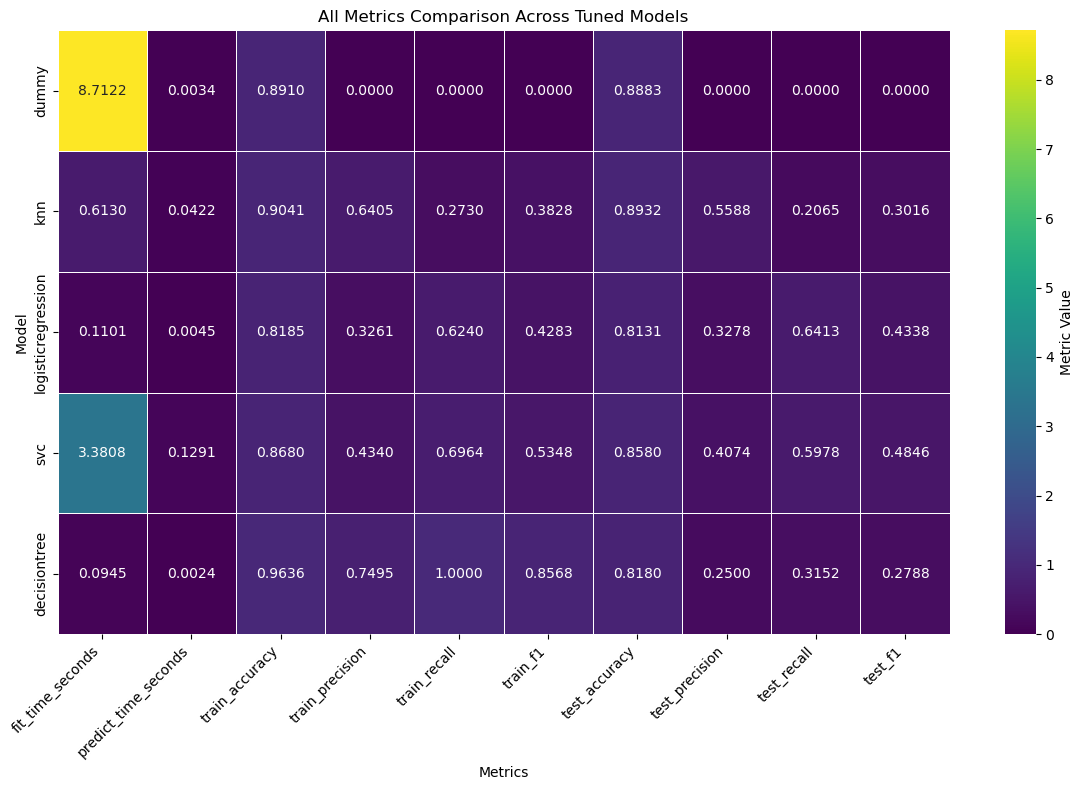

In [95]:


models = {
    'dummy': (DummyClassifier(), {
        'dummy__strategy': ['most_frequent', 'stratified']
    }),
    'knn': (KNeighborsClassifier(), {'knn__n_neighbors': [3, 5, 7]}),
    'logisticregression': (LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'), {'logisticregression__C': [0.01, 0.1, 1, 10]}),
    'svc': (SVC(class_weight='balanced'), {'svc__C': [0.1, 1, 10], 'svc__kernel': ['linear', 'rbf']}),
    'decisiontree': (DecisionTreeClassifier(class_weight='balanced'), {'decisiontree__max_depth': [5, 10, 15]})
}


best_model_metrics_sampled = []

for name, (model, param_grid) in models.items():
    pipeline = Pipeline([('preprocess', preprocessor), (name, model)])
    gs = GridSearchCV(pipeline, param_grid=param_grid, cv=5, n_jobs=-1, scoring='accuracy')

    # Measure fit time
    start_time_fit = time.time()
    gs.fit(X_sample_train, y_sample_train)
    fit_time_seconds = time.time() - start_time_fit

    best = gs.best_estimator_
    y_train_pred = best.predict(X_sample_train)

    # Measure predict time
    start_time_predict = time.time()
    y_test_pred = best.predict(X_sample_test)
    predict_time_seconds = time.time() - start_time_predict

    train_acc = accuracy_score(y_sample_train, y_train_pred)
    train_prec = precision_score(y_sample_train, y_train_pred, zero_division=0)
    train_rec = recall_score(y_sample_train, y_train_pred, zero_division=0)
    train_f1 = f1_score(y_sample_train, y_train_pred, zero_division=0)

    test_acc = accuracy_score(y_sample_test, y_test_pred)
    test_prec = precision_score(y_sample_test, y_test_pred, zero_division=0)
    test_rec = recall_score(y_sample_test, y_test_pred, zero_division=0)
    test_f1 = f1_score(y_sample_test, y_test_pred, zero_division=0)

    best_model_metrics_sampled.append({
        'model': name,
        'best_params': gs.best_params_,
        'fit_time_seconds': fit_time_seconds,
        'predict_time_seconds': predict_time_seconds,
        'train_accuracy': train_acc,
        'train_precision': train_prec,
        'train_recall': train_rec,
        'train_f1': train_f1,
        'test_accuracy': test_acc,
        'test_precision': test_prec,
        'test_recall': test_rec,
        'test_f1': test_f1
    })

    best_model_metrics_sampled_df = pd.DataFrame(best_model_metrics_sampled)


print("Best Tuned Model Metrics:")
display(best_model_metrics_sampled_df)

# Prepare data for heatmap visualization
heatmap_data_tuned = best_model_metrics_sampled_df.set_index('model').drop(columns=['best_params'])

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data_tuned, annot=True, cmap='viridis', fmt=".4f", linewidths=.5, cbar_kws={'label': 'Metric Value'})
plt.title('All Metrics Comparison Across Tuned Models')
plt.ylabel('Model')
plt.xlabel('Metrics')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.tight_layout()
plt.show()

Given the nature of the problem, and the results of the f1 score and recall in the previous test choosing to go with LogisticRegression as the modeler.  In this particular business problem, it is more important not to leave any potential on the table.  Precision is not as crucial.

*** Logistic Regression Feature Coefficients **

Fitting final Logistic Regression model...
Model fitting complete.


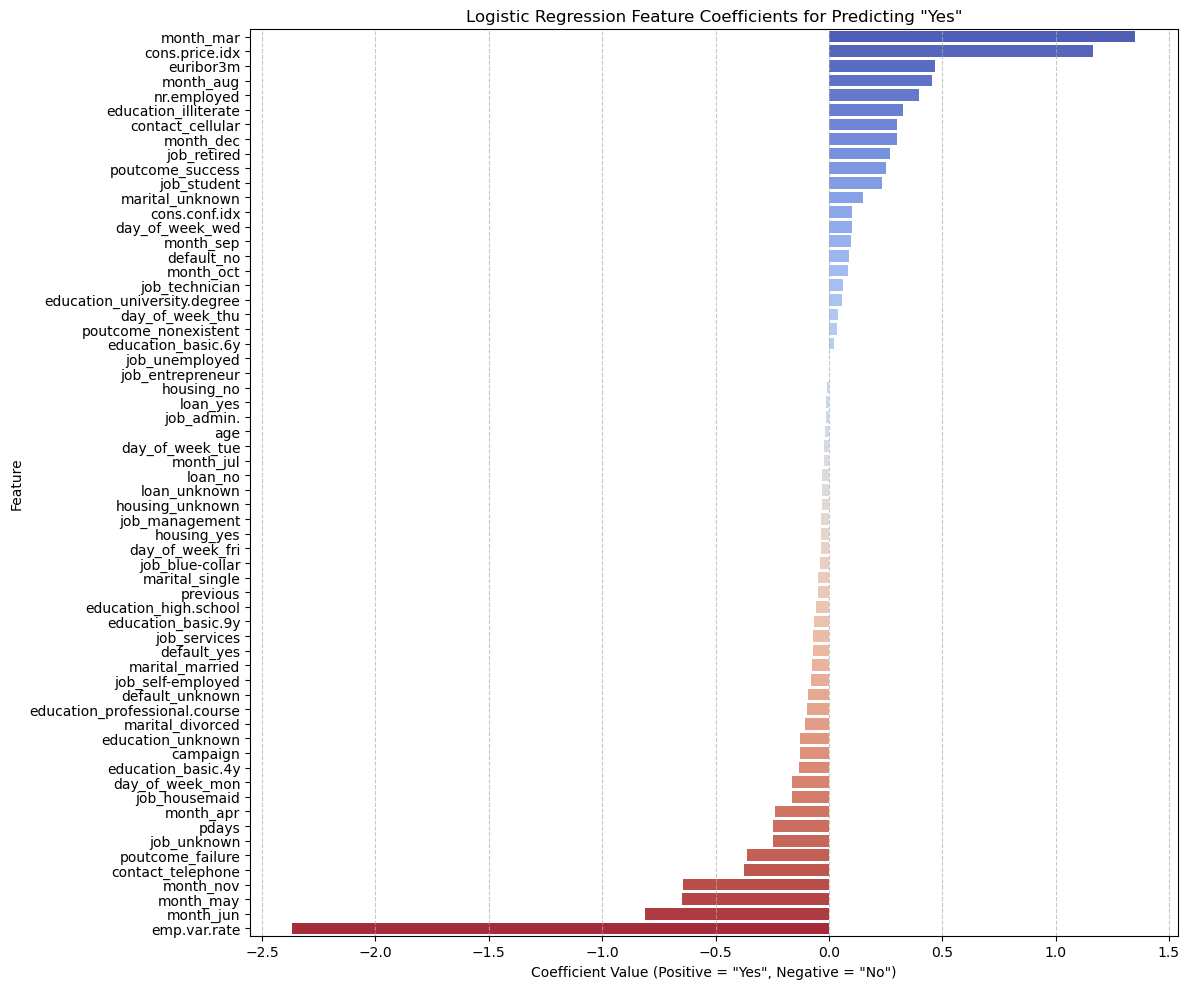


Top 10 features positively influencing a 'yes' subscription:


,Feature,Coefficient
40,month_mar,1.351762
58,cons.price.idx,1.164785
60,euribor3m,0.469480
36,month_aug,0.456832
61,nr.employed,0.397603
20,education_illiterate,0.328235
33,contact_cellular,0.302481
37,month_dec,0.299026
5,job_retired,0.269609
52,poutcome_success,0.253251



Top 10 features negatively influencing a 'yes' subscription:


,Feature,Coefficient
3,job_housemaid,-0.162523
35,month_apr,-0.235852
55,pdays,-0.244605
11,job_unknown,-0.248336
50,poutcome_failure,-0.362560
34,contact_telephone,-0.375961
42,month_nov,-0.645079
41,month_may,-0.647913
39,month_jun,-0.811018
57,emp.var.rate,-2.366705


Exception ignored in: <function ResourceTracker.__del__ at 0x1107cdc60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x118f61c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x103bb5c60>
Traceback (most recent call last

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the final Logistic Regression model with specified parameters
final_log_reg_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', C=10))
    ]
)

# 2. Fit the model
print("Fitting final Logistic Regression model...")
final_log_reg_pipeline.fit(X_train, y_train)
print("Model fitting complete.")

# 3. Extract coefficients
# The LogisticRegression model is the last step in the pipeline
logistic_model = final_log_reg_pipeline.named_steps['model']
coefficients = logistic_model.coef_[0] # Assuming binary classification, get coefficients for class 1

# 4. Get feature names
# Get names for one-hot encoded categorical features
feature_names_categorical = final_log_reg_pipeline.named_steps['preprocess'].named_transformers_['categorical'].get_feature_names_out(categorical_cols)

# Get names for numeric features
feature_names_numeric = numeric_cols.tolist()

# Combine all feature names
all_feature_names = np.concatenate([feature_names_categorical, feature_names_numeric])

# Create a DataFrame for better visualization
coef_df = pd.DataFrame({'Feature': all_feature_names, 'Coefficient': coefficients})

# Sort by coefficient value to easily see most influential features
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

# 5. Visualize coefficients
plt.figure(figsize=(12, 10))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='coolwarm', hue='Feature', legend=False) # Fixed FutureWarning
plt.title('Logistic Regression Feature Coefficients for Predicting "Yes"')
plt.xlabel('Coefficient Value (Positive = "Yes", Negative = "No")')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nTop 10 features positively influencing a 'yes' subscription:")
display(coef_df.head(10))

print("\nTop 10 features negatively influencing a 'yes' subscription:")
display(coef_df.tail(10))